In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# =========================
# 1️⃣ Charger le dataset
# =========================
df = pd.read_csv(r"C:\Users\Ph\Downloads\dataset_entretien_ml_regression.csv")


In [3]:
# =========================
# 2️⃣ Nettoyage
# =========================
print("Nombre de doublons avant :", df.duplicated().sum())
df = df.drop_duplicates()
print("Nombre de doublons après :", df.duplicated().sum())

numeric_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Valeurs manquantes après remplissage :")
print(df.isnull().sum())

Nombre de doublons avant : 20
Nombre de doublons après : 0
Valeurs manquantes après remplissage :
age                  0
revenu_mensuel       0
anciennete_annees    0
type_contrat         0
secteur              0
region               0
depense_annuelle     0
dtype: int64


<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                300 non-null    float64
 1   revenu_mensuel     300 non-null    float64
 2   anciennete_annees  300 non-null    int64  
 3   type_contrat       300 non-null    object 
 4   secteur            300 non-null    object 
 5   region             300 non-null    object 
 6   depense_annuelle   300 non-null    float64
dtypes: float64(3), int64(1), object(3)
memory usage: 18.8+ KB
None
              age  revenu_mensuel  anciennete_annees  depense_annuelle
count  300.000000      300.000000         300.000000      3.000000e+02
mean    41.018116   249811.793478           8.983333      1.515202e+06
std     12.932150    83000.817663           5.671886      5.339963e+05
min     18.000000   -19128.000000           0.000000      1.144190e+05
25%     31.000000   195212.500000           4.

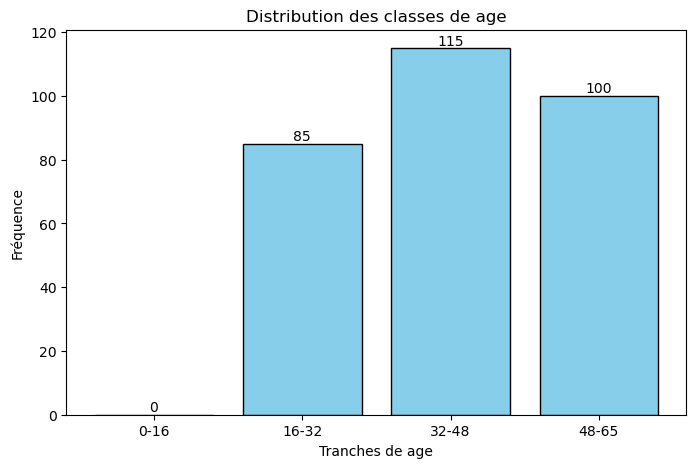

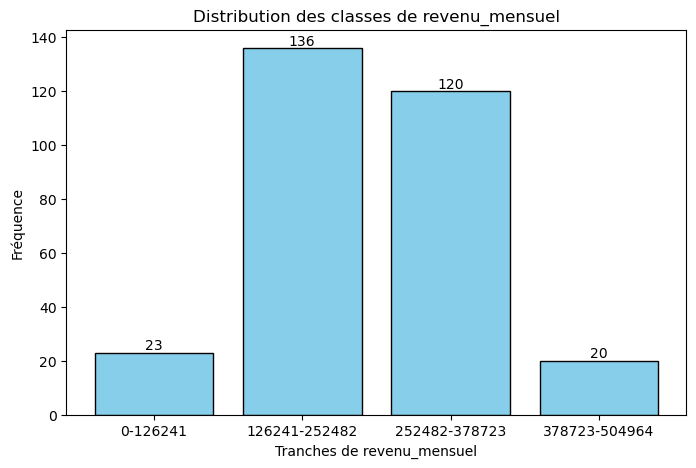

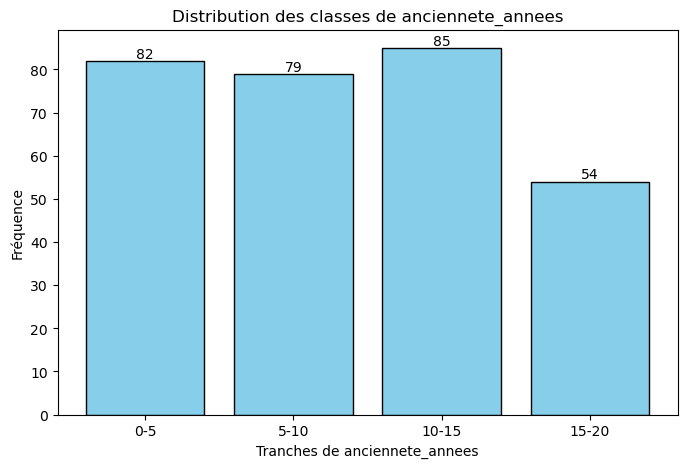

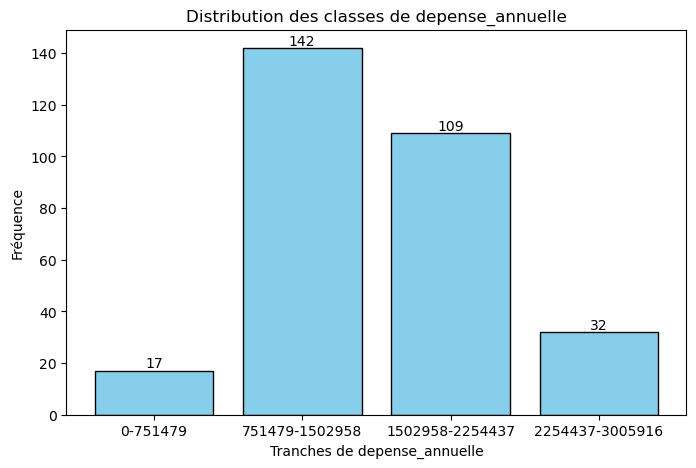

In [4]:
# =========================
# 3️⃣ Exploration
# =========================
print(df.info())
print(df.describe())

# Boucle sur toutes les colonnes numériques
for col in numeric_cols:
    # Création automatique des bins (4 classes) de 0 à max arrondi au multiple de 10 ou 20
    max_val = df[col].max()
    bins = np.linspace(0, max_val + 1, 5)  # 4 classes
    labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
    
    # Création de la colonne des classes
    df[f'{col}_group'] = pd.cut(df[col], bins=bins, labels=labels, right=False)
    
    # Comptage des fréquences
    counts = df[f'{col}_group'].value_counts().sort_index()
    
    # Histogramme avec étiquettes
    plt.figure(figsize=(8,5))
    bars = plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
    
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(bar.get_height()),
                 ha='center', va='bottom')
    
    plt.title(f"Distribution des classes de {col}")
    plt.xlabel(f"Tranches de {col}")
    plt.ylabel("Fréquence")
    plt.show()


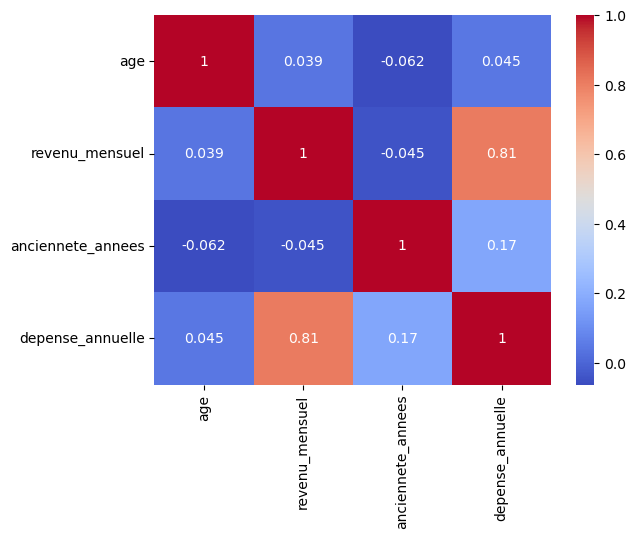

In [5]:
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

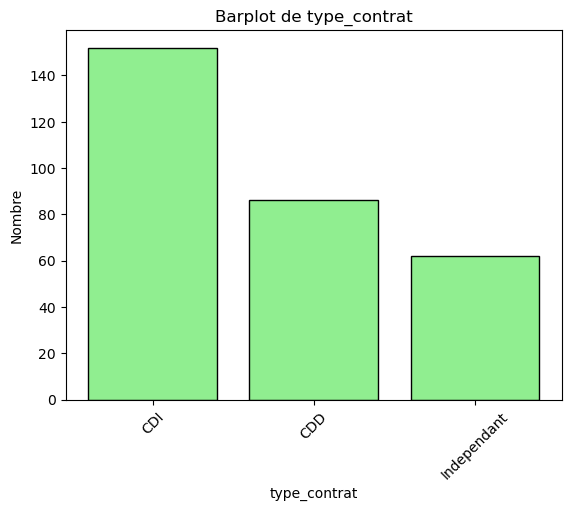

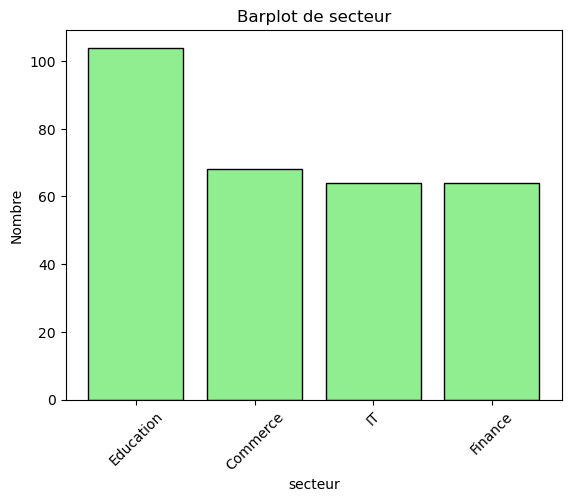

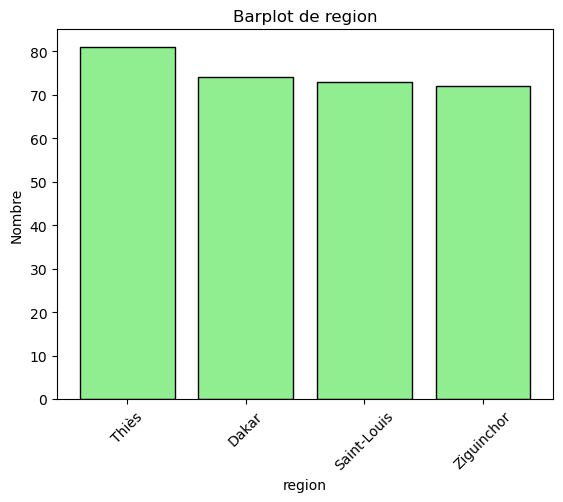

In [6]:
for col in cat_cols:
    counts = df[col].value_counts()
    plt.bar(counts.index, counts.values, color='lightgreen', edgecolor='black')
    plt.title(f"Barplot de {col}")
    plt.xlabel(col)
    plt.ylabel("Nombre")
    plt.xticks(rotation=45)
    plt.show()

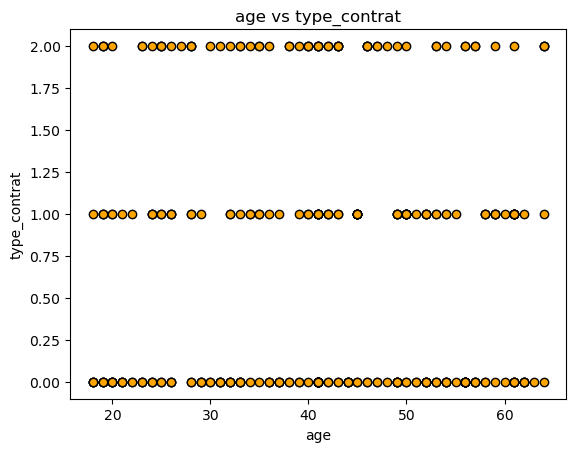

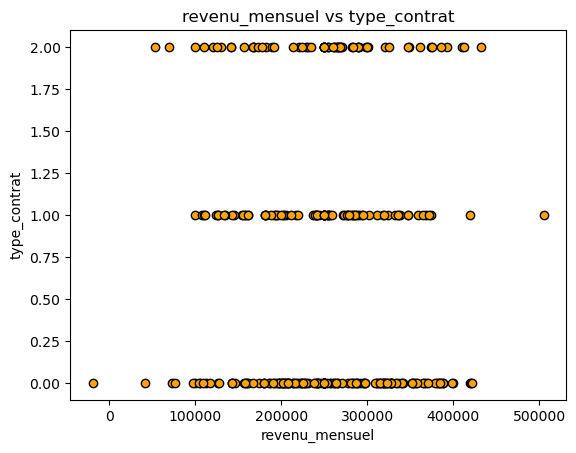

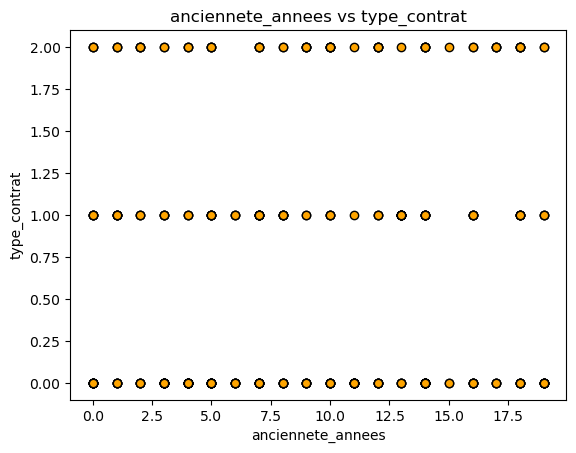

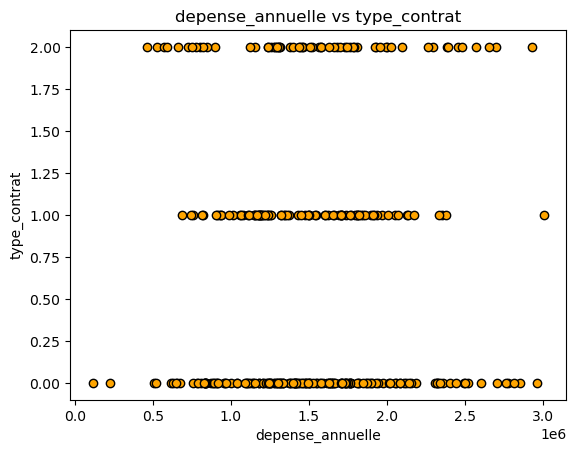

In [8]:
# Scatter plots pour les variables numériques
target_col = 'type_contrat'
for col in numeric_cols:
    plt.scatter(df[col], pd.factorize(df[target_col])[0], color='orange', edgecolor='black')
    plt.title(f"{col} vs {target_col}")
    plt.xlabel(col)
    plt.ylabel(target_col)
    plt.show()

In [9]:
# =========================
# 4️⃣ Préprocessing et split
# =========================
X = df.drop(target_col, axis=1)
y = df[target_col]

numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

standard_features = numeric_features[:1]
minmax_features = numeric_features[1:]

preprocessor = ColumnTransformer([
    ('standard', StandardScaler(), standard_features),
    ('minmax', MinMaxScaler(), minmax_features),
    ('cat', OneHotEncoder(), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# 5️⃣ Modèle et pipeline
# =========================
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipeline.fit(X_train, y_train)


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('standard', ...), ('minmax', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
# =========================
# 6️⃣ Prédiction et évaluation
# =========================
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.36666666666666664

Confusion Matrix:
[[ 1 14  2]
 [ 8 20  4]
 [ 2  8  1]]

Classification Report:
              precision    recall  f1-score   support

         CDD       0.09      0.06      0.07        17
         CDI       0.48      0.62      0.54        32
 Independant       0.14      0.09      0.11        11

    accuracy                           0.37        60
   macro avg       0.24      0.26      0.24        60
weighted avg       0.31      0.37      0.33        60



In [13]:
# ===========================================
# Prédiction du type de contrat pour de nouvelles données
# ===========================================

# 1️⃣ Préparer les nouvelles données
# -----------------------------
# Les colonnes doivent correspondre exactement à celles utilisées pour l'entraînement
X_new = pd.DataFrame({
    "age": [30, 45, 28],
    "revenu_mensuel": [2000, 5000, 1800],
    "anciennete_annees": [2, 10, 1],
    "depense_annuelle": [12000, 25000, 8000],
    "secteur": ["Education", "IT", "Commerce"],  # exemple de valeurs
    "region": ["Dakar", "Ziguinchor", "Dakar"]            # exemple de valeurs
})

# -----------------------------
# 2️⃣ Faire les prédictions
# -----------------------------
# 
y_new_pred = pipeline.predict(X_new)

# -----------------------------
# 3️⃣ Afficher les prédictions
# -----------------------------
print("Types de contrat prédits pour les nouveaux individus :")
for i, contrat in enumerate(y_new_pred):
    print(f"Individu {i+1} : {contrat}")

Types de contrat prédits pour les nouveaux individus :
Individu 1 : CDI
Individu 2 : Independant
Individu 3 : CDI
